
# Synthetic Drift: Dataset único + 3×Ventanas × 4×Métricas + Evaluación diaria

**Incluye:**  
- Generación de **1 dataset** (25–30 días, frecuencia horaria) con **10 variables numéricas**.  
- Inyección de **drift aleatorio** por variable (episodios **graduales** y **abruptos**), en general **sutiles**.  
- Etiquetas **por variable** (`drift_var_i`) y **global** (`drift_any`).  
- Columnas de **disponibilidad** `nd_var_i` (True = hay dato), guardadas en un **flags CSV** (se excluyen del cómputo).  
- Ejecución automática de **3 estrategias** (`decay`, `golden`, `seasonal`) × **4 métodos** (`ks`, `mannwhitney`, `psi`, `wasserstein`).  
- Evaluación **por día** (rolling `CURRENT_WINDOW="3D"`) con **TP, FP, TN, FN, Accuracy, Precision, Recall, F1** y **First Detection Delay**.  
- Escritura de resultados unificados por planta y globales + **CSV final de métricas**.



## 1) Parámetros
- `N_DAYS` aleatorio en **[25, 30]**  
- `N_VARS = 10`  
- Semilla reproducible  
- Directorios de salida


In [1]:

import numpy as np, pandas as pd
from pathlib import Path

import importlib.util

spec = importlib.util.spec_from_file_location("funciones_analisis", "../Analisis/Funciones_Drift.py")
funciones_analisis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(funciones_analisis)
run_drift_aggregate = funciones_analisis.run_drift_aggregate
compare_with_metric = funciones_analisis.compare_with_metric

# Reproducibilidad
rng = np.random.default_rng(2025)

# Parámetros base
N_DAYS = int(rng.integers(30, 46))   # 30–45 días
FREQ = "1H"
N_VARS = 10

PLANT_NAME = "synthetic_plant"
OUT_ROOT = Path("drift_results_v3")   # resultados (comparaciones y globales)
DATA_DIR = Path("synthetic_data_v3")  # datos simulados + flags + etiquetas
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"N_DAYS={N_DAYS}, N_VARS={N_VARS}")


N_DAYS=37, N_VARS=10



## 2) Generación del dataset + etiquetas de drift
- Cada `var_i` inicia como ruido `N(0,1)`  
- Por variable se eligen **1–3 episodios**; cada episodio puede ser:  
  - **Gradual:** rampa 0.2–0.6 por 1–5 días  
  - **Abrupto:** salto 0.8–1.5 mantenido  
- Se etiquetan `drift_var_i` y se construye `drift_any = OR(drift_var_*)`


In [2]:
# ===================== PARTE 2 — Generación + Etiquetas (realista, no superpuesta) =====================
# Requiere que ya existan: rng, N_DAYS, FREQ, N_VARS

import numpy as np
import pandas as pd

# -------------------- Configuración de intensidad y forma --------------------
INTENSITY_MODE = "sutil"   # opciones: "sutil" | "marcado"

# Rango de desplazamientos según modo
if INTENSITY_MODE == "marcado":
    GRADUAL_SHIFT_RANGE = (0.4, 1.2)   # total de rampa
    ABRUPT_JUMP_RANGE   = (1.2, 2.5)   # salto brusco
    NOISE_SIGMA         = 0.5          # ruido base (menor ruido → drift se ve más)
else:  # "sutil"
    GRADUAL_SHIFT_RANGE = (0.3, 0.8)
    ABRUPT_JUMP_RANGE   = (1.0, 2.0)
    NOISE_SIGMA         = 0.5

# AR(1) para dar inercia al ruido (más "físico")
AR1_PHI = 0.8    # 0 = ruido blanco, 0.7–0.9 = persistencia razonable

# Duraciones y gaps (en horas)
EPISODES_MIN_MAX    = (1, 11)        # 1–10 episodios por variable (upper bound no inclusivo)
MIN_GAP_HOURS       = 24             # separación mínima entre episodios de la MISMA variable
GRADUAL_DUR_RANGE   = (24, 24*5+1)   # 1–5 días de rampa
ABRUPT_LABEL_RANGE  = (8, 24+1)      # etiquetar 8–24 h alrededor del salto

# Umbral mínimo de impacto para etiquetar (en sigmas del ruido base)
IMPACT_MIN_SIGMAS   = 0.5            # si el efecto < 0.5σ, no se etiqueta ni aplica

# -------------------- Eje temporal y estructuras --------------------
dates = pd.date_range("2025-01-01", periods=N_DAYS*24, freq=FREQ, tz=None)
T = len(dates)
df = pd.DataFrame({"date_time": dates})

drift_flags = pd.DataFrame({"date_time": dates})
for i in range(1, N_VARS+1):
    drift_flags[f"drift_var_{i}"] = False

# -------------------- Helpers --------------------
def ar1_series(phi: float, sigma: float, size: int, rng=None):
    """Serie AR(1) con ruido N(0, sigma)."""
    if rng is None:
        rng = np.random.default_rng()
    x = np.zeros(size, dtype=float)
    x[0] = rng.normal(0.0, sigma)
    for t in range(1, size):
        x[t] = phi * x[t-1] + rng.normal(0.0, sigma)
    return x

def draw_non_overlapping_start(prev_end, max_start, min_gap):
    """
    Devuelve un start_idx >= prev_end + min_gap y < max_start.
    Si no hay espacio, retorna None.
    """
    earliest = prev_end + min_gap if prev_end is not None else 0
    if earliest >= max_start:
        return None
    return int(rng.integers(low=earliest, high=max_start))

# -------------------- Generación por variable --------------------
for i in range(1, N_VARS+1):
    # baseline con inercia (AR1) → el drift se aprecia mejor
    base = ar1_series(AR1_PHI, NOISE_SIGMA, T, rng=rng)
    base_std = np.std(base) if np.std(base) > 1e-9 else 1.0

    n_episodes = int(rng.integers(EPISODES_MIN_MAX[0], EPISODES_MIN_MAX[1]))  # 1–10
    prev_end = None  # fin del episodio anterior (en horas)

    for _ in range(n_episodes):
        drift_kind = rng.choice(["gradual", "abrupt"])

        if drift_kind == "gradual":
            dur_hours = int(rng.integers(*GRADUAL_DUR_RANGE))  # 1–5 días
            # Deja espacio para rampa completa y un gap posterior
            max_start = max(1, T - dur_hours - 1)
            start_idx = draw_non_overlapping_start(prev_end, max_start, MIN_GAP_HOURS)
            if start_idx is None:
                break
            end_idx = start_idx + dur_hours

            total_shift = float(rng.uniform(*GRADUAL_SHIFT_RANGE))
            # Chequeo de impacto (evita etiquetar cambios imperceptibles)
            impact = abs(total_shift) / max(base_std, 1e-9)
            if impact < IMPACT_MIN_SIGMAS:
                continue

            ramp = np.linspace(0.0, total_shift, end_idx - start_idx + 1)
            base[start_idx:end_idx+1] += ramp

            # Etiquetar SOLO la rampa
            drift_flags.loc[start_idx:end_idx, f"drift_var_{i}"] = True
            prev_end = end_idx

        else:  # abrupt
            label_hours = int(rng.integers(*ABRUPT_LABEL_RANGE))
            max_start = max(1, T - label_hours - 1)
            start_idx = draw_non_overlapping_start(prev_end, max_start, MIN_GAP_HOURS)
            if start_idx is None:
                break
            end_idx = start_idx + label_hours

            jump = float(rng.uniform(*ABRUPT_JUMP_RANGE))
            impact = abs(jump) / max(base_std, 1e-9)
            if impact < IMPACT_MIN_SIGMAS:
                continue

            # El valor salta y se estabiliza en el nuevo nivel
            base[start_idx:] += jump
            # Etiquetar SOLO alrededor del cambio brusco (ventana corta)
            drift_flags.loc[start_idx:end_idx, f"drift_var_{i}"] = True
            prev_end = end_idx

    df[f"var_{i}"] = base

# Etiqueta global (cualquier variable en cambio)
drift_cols = [c for c in drift_flags.columns if c.startswith("drift_var_")]
drift_flags["drift_any"] = drift_flags[drift_cols].any(axis=1)

# --- Resumen rápido: episodios marcados por variable ---
def count_intervals(b):
    b = b.astype(bool).values
    cnt = 0; on = False
    for v in b:
        if v and not on: cnt += 1; on = True
        elif not v and on: on = False
    return cnt

episodios = {f"var_{k}": count_intervals(drift_flags[f"drift_var_{k}"]) for k in range(1, N_VARS+1)}
print("Episodios por variable:", episodios)
df.head(3), drift_flags.head(3), drift_flags["drift_any"].mean()


Episodios por variable: {'var_1': 2, 'var_2': 3, 'var_3': 2, 'var_4': 3, 'var_5': 2, 'var_6': 2, 'var_7': 4, 'var_8': 3, 'var_9': 3, 'var_10': 2}


(            date_time     var_1     var_2     var_3     var_4     var_5  \
 0 2025-01-01 00:00:00  0.013000 -0.128665 -0.682975  0.146803  0.565996   
 1 2025-01-01 01:00:00 -0.259085 -0.883138 -0.466233 -0.200898  1.432995   
 2 2025-01-01 02:00:00 -0.771864 -0.219895 -0.727916 -0.388083  1.483046   
 
       var_6     var_7     var_8     var_9    var_10  
 0 -0.271052 -0.059284  0.507560  0.489097  0.677737  
 1  0.459322 -0.398179  1.236698  0.200576  0.669603  
 2 -0.323374 -1.053131  2.006510  0.152869  0.479440  ,
             date_time  drift_var_1  drift_var_2  drift_var_3  drift_var_4  \
 0 2025-01-01 00:00:00        False        False        False        False   
 1 2025-01-01 01:00:00        False        False        False        False   
 2 2025-01-01 02:00:00        False        False        False        False   
 
    drift_var_5  drift_var_6  drift_var_7  drift_var_8  drift_var_9  \
 0        False        False        False        False        False   
 1        False  


## 3) Visualización del drift
### 3.1 Por variable (sombreado con `drift_var_i`)


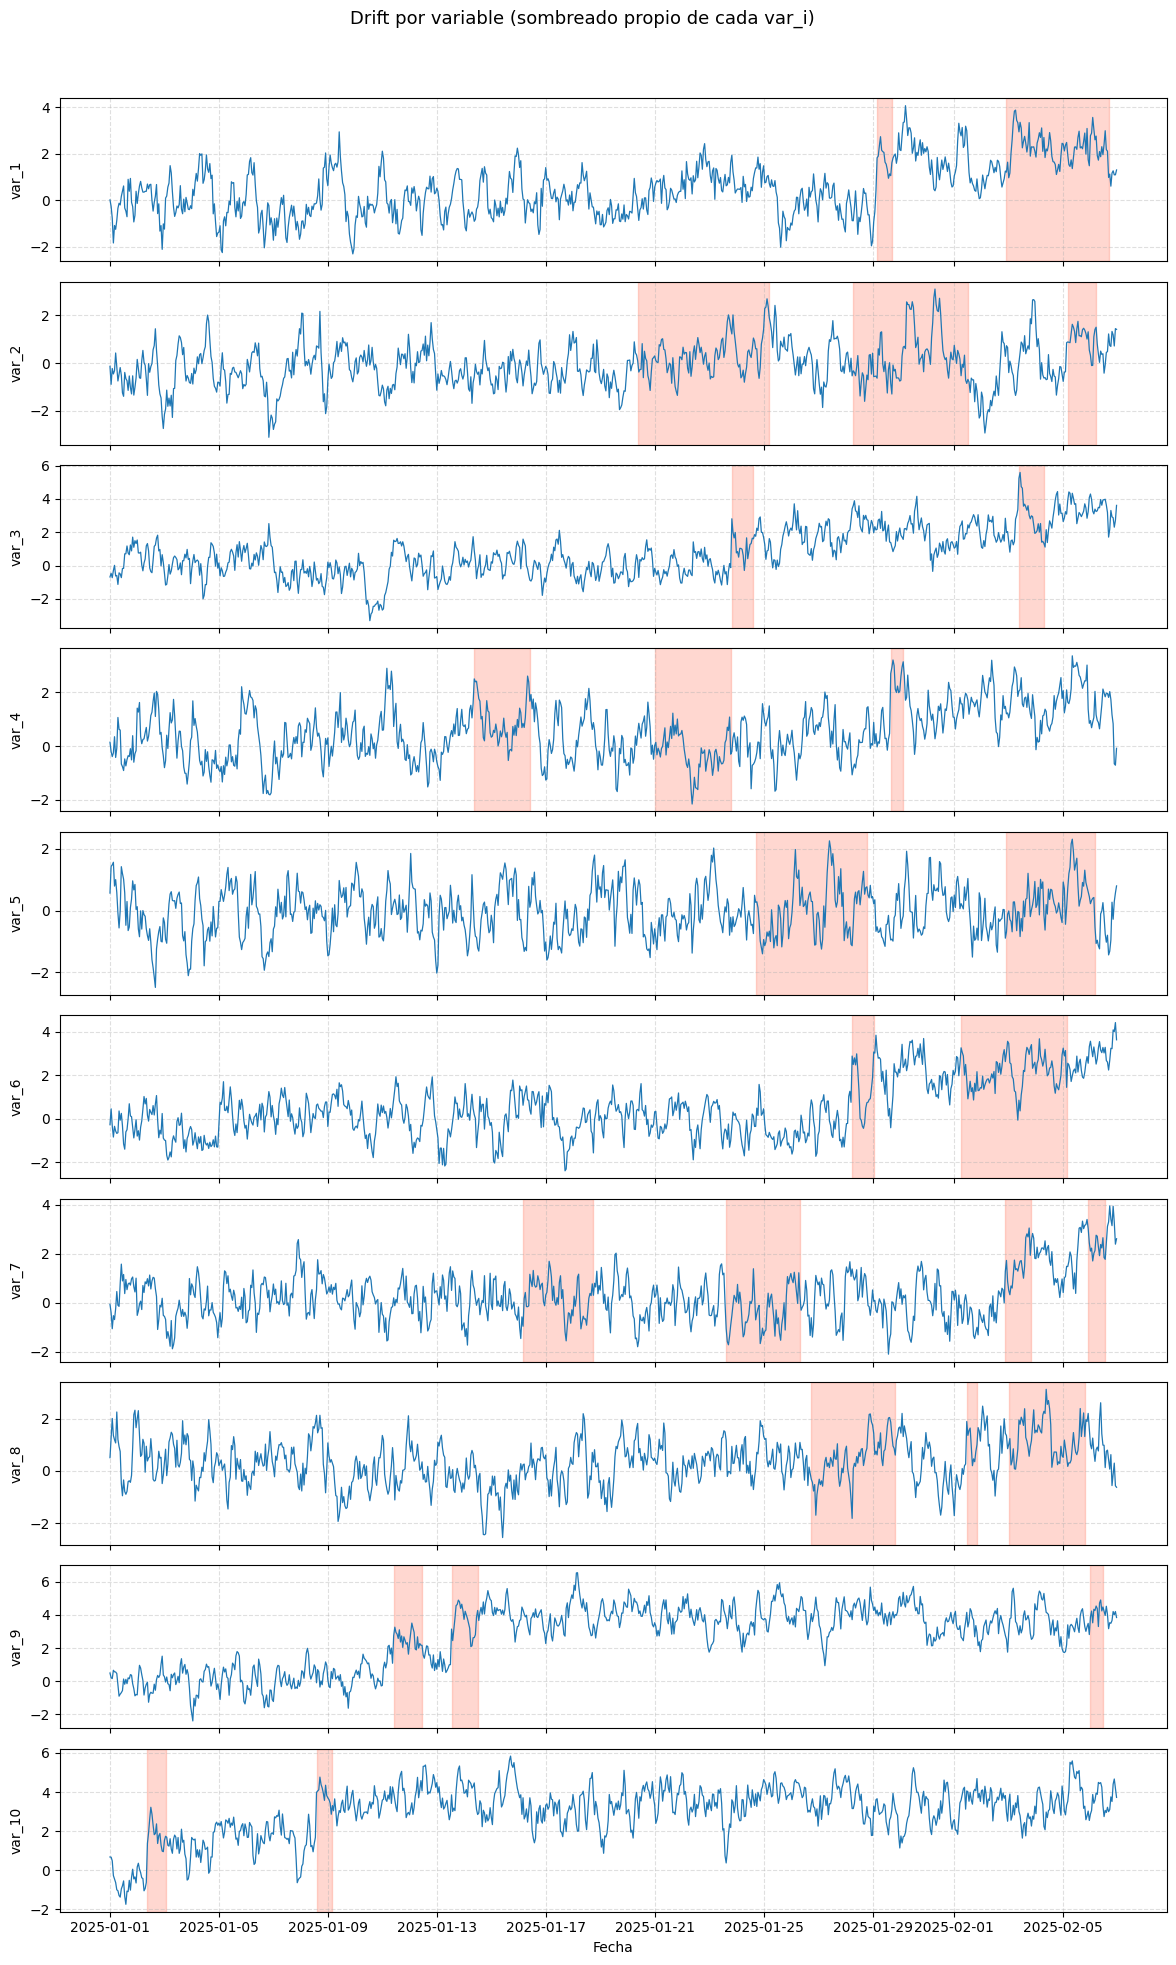

In [3]:

import matplotlib.pyplot as plt

vars_to_plot = [f"var_{i}" for i in range(1, N_VARS+1)]
times = df["date_time"]

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(12, 2.0*len(vars_to_plot)), sharex=True)
for ax, v in zip(axes, vars_to_plot):
    ax.plot(times, df[v], lw=0.9, label=v)
    mask = drift_flags["drift_" + v].astype(bool).values
    in_drift = False; start = None
    for i in range(len(mask)):
        if mask[i] and not in_drift:
            start = times[i]; in_drift = True
        elif not mask[i] and in_drift:
            ax.axvspan(start, times[i], color="tomato", alpha=0.25); in_drift = False
    if in_drift:
        ax.axvspan(start, times.iloc[-1], color="tomato", alpha=0.25)
    ax.set_ylabel(v); ax.grid(True, ls="--", alpha=0.4)
axes[-1].set_xlabel("Fecha")
fig.suptitle("Drift por variable (sombreado propio de cada var_i)", fontsize=13)
plt.tight_layout(rect=[0,0,1,0.96]); plt.show()



### 3.2 Tabla de intervalos por variable


In [4]:

rows = []
for i in range(1, N_VARS+1):
    lab = f"drift_var_{i}"
    s = drift_flags[lab].astype(bool)
    intervals = []
    in_drift = False; t0 = None
    for t, val in zip(df["date_time"], s):
        if val and not in_drift:
            t0 = t; in_drift = True
        elif not val and in_drift:
            intervals.append((t0, t)); in_drift = False
    if in_drift:
        intervals.append((t0, df["date_time"].iloc[-1]))
    if intervals:
        rows.append({"var": f"var_{i}", "n_episodios": len(intervals),
                     "primer_inicio": intervals[0][0], "ultimo_fin": intervals[-1][1]})
    else:
        rows.append({"var": f"var_{i}", "n_episodios": 0,
                     "primer_inicio": None, "ultimo_fin": None})
pd.DataFrame(rows)


,var,n_episodios,primer_inicio,ultimo_fin
0,var_1,2,2025-01-29 04:00:00,2025-02-06 16:00:00
1,var_2,3,2025-01-20 09:00:00,2025-02-06 05:00:00
2,var_3,2,2025-01-23 20:00:00,2025-02-04 07:00:00
3,var_4,3,2025-01-14 09:00:00,2025-01-30 03:00:00
4,var_5,2,2025-01-24 17:00:00,2025-02-06 04:00:00
5,var_6,2,2025-01-28 06:00:00,2025-02-05 03:00:00
6,var_7,4,2025-01-16 04:00:00,2025-02-06 13:00:00
7,var_8,3,2025-01-26 18:00:00,2025-02-05 19:00:00
8,var_9,3,2025-01-11 10:00:00,2025-02-06 11:00:00
9,var_10,2,2025-01-02 09:00:00,2025-01-09 04:00:00



### 3.3 Heatmap (tiempo × variable) de drift


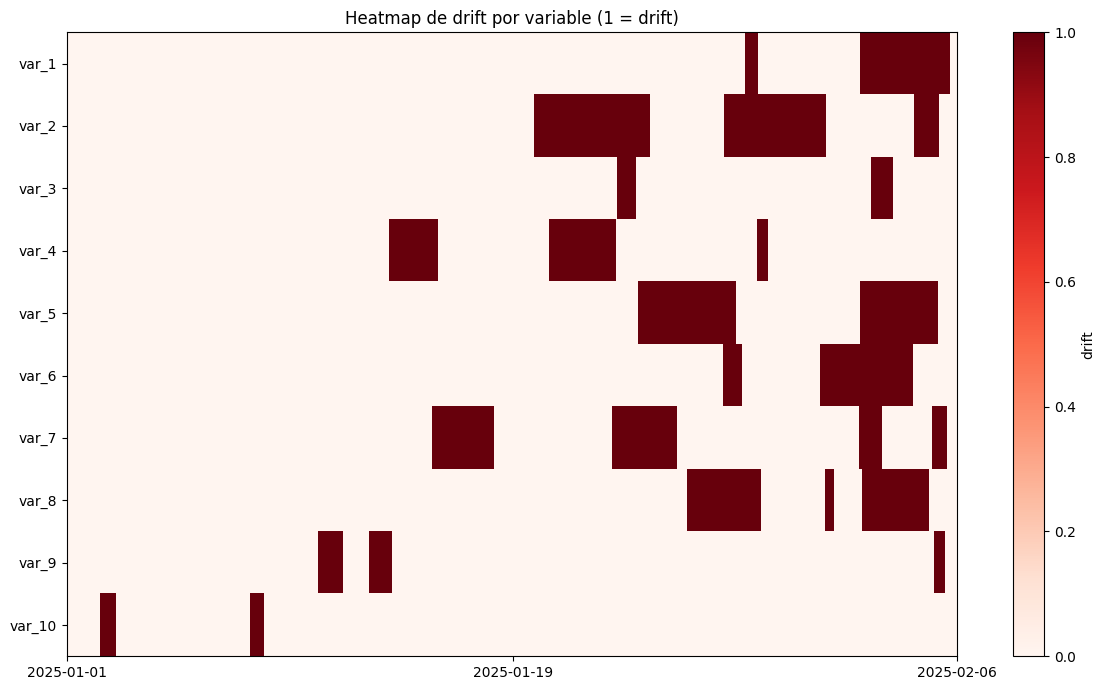

In [5]:

lab_cols = [c for c in drift_flags.columns if c.startswith("drift_var_")]
M = drift_flags[lab_cols].astype(int).to_numpy().T

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 0.5*len(lab_cols)+2))
plt.imshow(M, aspect="auto", interpolation="nearest", cmap="Reds")
plt.yticks(range(len(lab_cols)), [c.replace("drift_","") for c in lab_cols])
plt.xticks([0, len(df)//2, len(df)-1],
           [str(df["date_time"].iloc[0].date()),
            str(df["date_time"].iloc[len(df)//2].date()),
            str(df["date_time"].iloc[-1].date())])
plt.title("Heatmap de drift por variable (1 = drift)")
plt.colorbar(label="drift"); plt.tight_layout(); plt.show()



## 4) Disponibilidad (`nd_var_i`) + guardado de CSVs
- Se crean `nd_var_i` con **bloques faltantes** (1–3 por variable).  
- Estas columnas **no** entran al cómputo de drift (se excluyen).


In [6]:

# Flags de disponibilidad
flags = pd.DataFrame({"date_time": dates})
for i in range(1, N_VARS+1):
    nd = np.ones(len(dates), dtype=bool)
    n_blocks = int(rng.integers(1, 4))  # 1–3 bloques
    for _ in range(n_blocks):
        b_len = int(rng.integers(6, 24*2))  # 6 horas a 2 días
        b_start = int(rng.integers(0, max(1, len(dates)-b_len)))
        nd[b_start:b_start+b_len] = False
    flags[f"nd_var_{i}"] = nd

# (Opcional) vista enmascarada
df_masked = df.copy()
for i in range(1, N_VARS+1):
    mask = flags[f"nd_var_{i}"]
    df_masked.loc[~mask, f"var_{i}"] = np.nan

# Guardar artefactos
DATA_DIR.mkdir(parents=True, exist_ok=True)
plant_csv  = DATA_DIR / f"{PLANT_NAME}.csv"
flags_csv  = DATA_DIR / f"{PLANT_NAME}_flags.csv"
labels_csv = DATA_DIR / f"{PLANT_NAME}_labels.csv"

df.to_csv(plant_csv, index=False)
flags.to_csv(flags_csv, index=False)
drift_flags.to_csv(labels_csv, index=False)

plant_csv, flags_csv, labels_csv


(WindowsPath('synthetic_data_v3/synthetic_plant.csv'),
 WindowsPath('synthetic_data_v3/synthetic_plant_flags.csv'),
 WindowsPath('synthetic_data_v3/synthetic_plant_labels.csv'))


## 5) Detección de drift (3× estrategias × 4× métodos) — CSVs unificados


In [7]:
plant_files = {PLANT_NAME: plant_csv}
flag_files  = {PLANT_NAME: flags_csv}

# Excluir nd_* y drift_* del cómputo
EXCLUDE_COLUMNS = [c for c in flags.columns if c.startswith("nd_")] +                   [c for c in drift_flags.columns if c.startswith("drift_")]

paths = run_drift_aggregate(
    plant_names=[PLANT_NAME],
    strategies=["decay","golden","seasonal"],
    plant_files=plant_files,
    flag_files=flag_files,
    output_root=OUT_ROOT,
    metrics=["ks","mannwhitney","psi","wasserstein"],
    CURRENT_WINDOW="3D",
    RESAMPLE=None,
    RESAMPLE_AGG="mean",
    EXCLUDE_COLUMNS=EXCLUDE_COLUMNS,
    WRITE_GLOBAL=True
)
paths


{'synthetic_plant': {'columns': WindowsPath('drift_results_v3/synthetic_plant/_comparisons/synthetic_plant_columns_all_metrics.csv'),
  'summary': WindowsPath('drift_results_v3/synthetic_plant/_comparisons/synthetic_plant_summary_all_metrics.csv')}}


## 6) Evaluación diaria (TP/FP/TN/FN, Accuracy, Precision, Recall, F1) + Delay
Usa rolling con `CURRENT_WINDOW="3D"` y compara contra `drift_any` diario.


In [8]:
import numpy as np
import pandas as pd

# Verdad diaria
labels_df = pd.read_csv(labels_csv, parse_dates=["date_time"])
truth_daily = (labels_df.set_index("date_time")["drift_any"]
               .resample("1D").max().astype(int).reset_index()
               .rename(columns={"date_time":"date","drift_any":"y_true"}))

strategies = ["decay","golden","seasonal"]
metrics = ["ks","mannwhitney","psi","wasserstein"]
CURRENT_WINDOW = "1D"

EXCLUDE_COLUMNS = [c for c in flags.columns if c.startswith("nd_")] +                   [c for c in drift_flags.columns if c.startswith("drift_")]

start_date = df["date_time"].min() + pd.to_timedelta(CURRENT_WINDOW)
end_date   = df["date_time"].max()
eval_days  = pd.date_range(start_date.normalize(), end_date.normalize(), freq="1D")

pred_frames = []
for strat in strategies:
    for met in metrics:
        rows = []
        for day in eval_days:
            df_slice = df[df["date_time"] <= (day + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()
            if df_slice.empty:
                continue
            dfm, overall = compare_with_metric(
                df=df_slice, strategy=strat, metric=met,
                CURRENT_WINDOW=CURRENT_WINDOW, RESAMPLE=None, RESAMPLE_AGG="mean",
                EXCLUDE_COLUMNS=EXCLUDE_COLUMNS, num_threshold=None, save_html=False
            )
            y_pred = int(bool(dfm["drift_detected"].fillna(False).any())) if dfm is not None and not dfm.empty else 0
            rows.append({"date": day.normalize(), "strategy": strat, "metric": met, "y_pred": y_pred})
        pred_frames.append(pd.DataFrame(rows))
df_preds_daily = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()

df_eval_daily = (df_preds_daily.merge(truth_daily, on="date", how="inner")
                 .assign(
                    TP=lambda d: ((d.y_pred==1) & (d.y_true==1)).astype(int),
                    TN=lambda d: ((d.y_pred==0) & (d.y_true==0)).astype(int),
                    FP=lambda d: ((d.y_pred==1) & (d.y_true==0)).astype(int),
                    FN=lambda d: ((d.y_pred==0) & (d.y_true==1)).astype(int),
                 ))

def _agg_metrics(g):
    tp, fp, tn, fn = g["TP"].sum(), g["FP"].sum(), g["TN"].sum(), g["FN"].sum()
    acc = (tp+tn) / max(tp+tn+fp+fn, 1)
    prec = tp / max(tp+fp, 1)
    rec  = tp / max(tp+fn, 1)
    f1   = (2*prec*rec)/max(prec+rec, 1e-9)
    return pd.Series(dict(TP=tp, FP=fp, TN=tn, FN=fn,
                          Accuracy=acc, Precision=prec, Recall=rec, F1=f1))

df_scores = df_eval_daily.groupby(["strategy","metric"]).apply(_agg_metrics).reset_index()
df_scores.sort_values(["strategy","metric"], inplace=True)

first_truth_day = truth_daily.query("y_true==1")["date"].min()
rows = []
for (strat, met), g in df_eval_daily.groupby(["strategy","metric"]):
    first_pred_day = g.loc[g["y_pred"]==1, "date"].min()
    if pd.isna(first_truth_day):
        delay = np.nan
    elif pd.isna(first_pred_day):
        delay = None   # no detectado
    else:
        delay = (first_pred_day - first_truth_day).days
    rows.append({"strategy": strat, "metric": met, "First_Detection_Delay_days": delay})
df_delay = pd.DataFrame(rows)

df_final = df_scores.merge(df_delay, on=["strategy","metric"], how="left")
metrics_csv = OUT_ROOT / "GLOBAL_eval_daily_metrics.csv"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
df_final.to_csv(metrics_csv, index=False)

df_final, metrics_csv


(    strategy       metric    TP   FP   TN    FN  Accuracy  Precision  \
 0      decay           ks  30.0  6.0  0.0   0.0  0.833333   0.833333   
 1      decay  mannwhitney  29.0  6.0  0.0   1.0  0.805556   0.828571   
 2      decay          psi  30.0  6.0  0.0   0.0  0.833333   0.833333   
 3      decay  wasserstein  30.0  6.0  0.0   0.0  0.833333   0.833333   
 4     golden           ks  30.0  6.0  0.0   0.0  0.833333   0.833333   
 5     golden  mannwhitney  27.0  6.0  0.0   3.0  0.750000   0.818182   
 6     golden          psi  30.0  6.0  0.0   0.0  0.833333   0.833333   
 7     golden  wasserstein  30.0  6.0  0.0   0.0  0.833333   0.833333   
 8   seasonal           ks   4.0  4.0  2.0  26.0  0.166667   0.500000   
 9   seasonal  mannwhitney   2.0  4.0  2.0  28.0  0.111111   0.333333   
 10  seasonal          psi   4.0  4.0  2.0  26.0  0.166667   0.500000   
 11  seasonal  wasserstein   4.0  4.0  2.0  26.0  0.166667   0.500000   
 
       Recall        F1  First_Detection_Delay_da


### 6.1 Gráficos rápidos (Recall y F1)


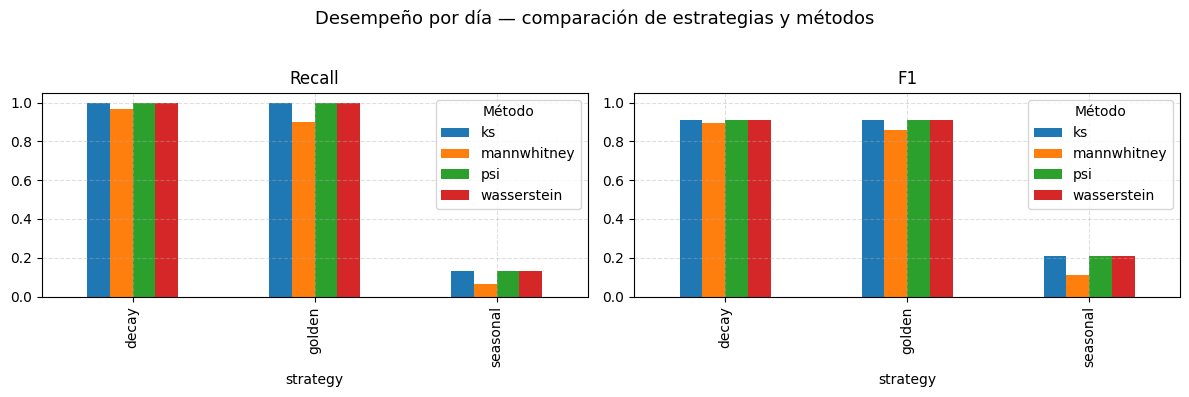

In [9]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col in zip(axes, ["Recall","F1"]):
    piv = df_final.pivot(index="strategy", columns="metric", values=col)
    piv.plot(kind="bar", ax=ax)
    ax.set_title(col); ax.set_ylim(0, 1.05); ax.grid(True, ls="--", alpha=0.4); ax.legend(title="Método")
plt.suptitle("Desempeño por día — comparación de estrategias y métodos", fontsize=13)
plt.tight_layout(rect=[0,0,1,0.95]); plt.show()


In [10]:
# === 7A — Predicciones por variable y por día (robusto a distintos esquemas de dfm) ===
import pandas as pd
import numpy as np

# ---------- utilidades ----------
def _norm(s):
    return s.strip().lower().replace(" ", "_") if isinstance(s, str) else s

def _find_col(dfm, candidates):
    for c in candidates:
        if c in dfm.columns:
            return c
    # también considerar índice
    if dfm.index.name in candidates:
        return dfm.index.name
    return None

def _extract_per_var_flags(dfm, var_names):
    """
    Devuelve un dict {var_i: 0/1} con detección por variable, intentando cubrir:
    - formato largo: columnas tipo ['column'|'variable'|'feature', 'drift_detected'|'detected'|'drift']
    - formato ancho: columnas 'var_1', 'var_2', ... con 0/1
    - formato ancho con sufijos: 'var_1_drift_detected', etc.
    Si no se puede, retorna todo 0.
    """
    detected = {v: 0 for v in var_names}
    if dfm is None or dfm.empty:
        return detected

    # normalizar nombres de columnas
    dfm_cols_norm = {_norm(c): c for c in dfm.columns}
    inv_norm = {v: k for k, v in dfm_cols_norm.items()}

    # 1) Formato largo
    var_col = _find_col(dfm, ["column", "variable", "feature", "var", "name"])
    flag_col = _find_col(dfm, ["drift_detected", "drift_flag", "drift", "flag", "detected"])
    if var_col and flag_col:
        # tomar del índice si corresponde
        if var_col not in dfm.columns and dfm.index.name == var_col:
            series_var = dfm.index.to_series()
            df_tmp = dfm.copy()
            df_tmp[var_col] = series_var.values
        else:
            df_tmp = dfm

        for _, r in df_tmp.iterrows():
            v_raw = r[var_col]
            v_norm = _norm(v_raw)
            # emparejar con nombres de var_*
            for v in var_names:
                if _norm(v) == v_norm:
                    detected[v] = int(bool(r[flag_col]))
                    break
        return detected

    # 2) Formato ancho directo: columnas = var_i con 0/1
    hits = 0
    for v in var_names:
        if v in dfm.columns:
            try:
                detected[v] = int(bool(dfm[v].iloc[-1]))
                hits += 1
            except Exception:
                pass
    if hits:
        return detected

    # 3) Formato ancho con sufijos/prefijos
    # buscar columnas que contengan el nombre de la variable y algún token de drift
    drift_tokens = ["drift_detected", "detected", "drift", "flag"]
    cols = list(dfm.columns)
    for v in var_names:
        vnorm = _norm(v)
        for c in cols:
            cnorm = _norm(c)
            if vnorm in cnorm and any(tok in cnorm for tok in drift_tokens):
                try:
                    detected[v] = int(bool(dfm[c].iloc[-1]))
                    break
                except Exception:
                    pass

    return detected

# ---------- verdad diaria por variable ----------
truth_var_daily_list = []
for i in range(1, N_VARS+1):
    s = drift_flags.set_index("date_time")[f"drift_var_{i}"].resample("1D").max().astype(int)
    truth_var_daily_list.append(s.rename(f"drift_var_{i}"))
truth_var_daily = (
    pd.concat(truth_var_daily_list, axis=1)
    .reset_index()
    .rename(columns={"date_time": "date"})
)

# ---------- parámetros ----------
strategies = ["decay", "golden", "seasonal"]
metrics = ["ks", "mannwhitney", "psi", "wasserstein"]
CURRENT_WINDOW = "3D"
EXCLUDE_COLUMNS = [c for c in flags.columns if c.startswith("nd_")] + \
                  [c for c in drift_flags.columns if c.startswith("drift_")]
var_names = [f"var_{i}" for i in range(1, N_VARS+1)]

# ---------- rango de días evaluables ----------
start_date = df["date_time"].min() + pd.to_timedelta(CURRENT_WINDOW)
end_date   = df["date_time"].max()
eval_days  = pd.date_range(start_date.normalize(), end_date.normalize(), freq="1D")

# ---------- loop principal ----------
rows = []
for strat in strategies:
    for met in metrics:
        for day in eval_days:
            df_slice = df[df["date_time"] <= (day + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))].copy()
            if df_slice.empty:
                continue
            dfm, overall = compare_with_metric(
                df=df_slice, strategy=strat, metric=met,
                CURRENT_WINDOW=CURRENT_WINDOW, RESAMPLE=None, RESAMPLE_AGG="mean",
                EXCLUDE_COLUMNS=EXCLUDE_COLUMNS, num_threshold=None, save_html=False
            )

            detected = _extract_per_var_flags(dfm, var_names)

            for v in var_names:
                rows.append({
                    "date": day.normalize(),
                    "strategy": strat,
                    "metric": met,
                    "var": v,
                    "y_pred_var": detected[v],
                })

df_preds_var_daily = pd.DataFrame(rows)
print("Predicciones por var/día:", df_preds_var_daily.shape)
print(df_preds_var_daily.groupby(["strategy","metric"])["y_pred_var"].sum())
df_preds_var_daily.head()


Predicciones por var/día: (4080, 5)
strategy  metric     
decay     ks             0
          mannwhitney    0
          psi            0
          wasserstein    0
golden    ks             0
          mannwhitney    0
          psi            0
          wasserstein    0
seasonal  ks             0
          mannwhitney    0
          psi            0
          wasserstein    0
Name: y_pred_var, dtype: int64


,date,strategy,metric,var,y_pred_var
0,2025-01-04,decay,ks,var_1,0
1,2025-01-04,decay,ks,var_2,0
2,2025-01-04,decay,ks,var_3,0
3,2025-01-04,decay,ks,var_4,0
4,2025-01-04,decay,ks,var_5,0


In [11]:
# === 7B — Una variable, una combinación (con solapes rojo/verde) ===
import matplotlib.pyplot as plt

def _mask_to_intervals(x_dates, mask_bool):
    intervals = []
    in_on = False; t0 = None
    for t, val in zip(x_dates, mask_bool):
        if val and not in_on:
            t0 = t; in_on = True
        elif not val and in_on:
            intervals.append((t0, t)); in_on = False
    if in_on:
        intervals.append((t0, x_dates[-1] + pd.Timedelta(days=1)))
    return intervals

def plot_var_with_labels_and_detections(var_idx=1, strategy="decay", metric="ks"):
    v = f"var_{var_idx}"
    times_h = df["date_time"]
    series = df[v]

    gt = truth_var_daily[["date", f"drift_var_{var_idx}"]].rename(columns={f"drift_var_{var_idx}":"y_true"})
    pred = df_preds_var_daily.query(
        "strategy == @strategy and metric == @metric and var == @v"
    ).loc[:, ["date", "y_pred_var"]]

    base_dates = pd.date_range(truth_var_daily["date"].min(), truth_var_daily["date"].max(), freq="1D")
    gt   = gt.set_index("date").reindex(base_dates, fill_value=0).reset_index().rename(columns={"index":"date"})
    pred = pred.set_index("date").reindex(base_dates, fill_value=0).reset_index().rename(columns={"index":"date"})

    gt_intervals   = _mask_to_intervals(gt["date"].tolist(),   gt["y_true"].astype(bool).tolist())
    pred_intervals = _mask_to_intervals(pred["date"].tolist(), pred["y_pred_var"].astype(bool).tolist())

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(times_h, series, lw=0.9, color="black", label=v)

    for (t0, t1) in gt_intervals:
        ax.axvspan(t0, t1, color="tomato", alpha=0.22, zorder=1, label="Etiqueta (drift)")
    for idx, (t0, t1) in enumerate(pred_intervals):
        ax.axvspan(t0, t1, color="mediumseagreen", alpha=0.22, zorder=2,
                   label="Detección modelo" if idx == 0 else None)

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper left")

    ax.set_title(f"{v} — {strategy}/{metric}")
    ax.set_xlabel("Fecha"); ax.set_ylabel(v)
    ax.grid(True, ls="--", alpha=0.35)
    plt.tight_layout(); plt.show()

# Ejemplo
# plot_var_with_labels_and_detections(var_idx=1, strategy="golden", metric="psi")


In [12]:
def panel_var_all_methods(var_idx=1):
    v = f"var_{var_idx}"
    base_dates = pd.date_range(truth_var_daily["date"].min(), truth_var_daily["date"].max(), freq="1D")

    gt = truth_var_daily[["date", f"drift_var_{var_idx}"]].rename(columns={f"drift_var_{var_idx}":"y_true"})
    gt = gt.set_index("date").reindex(base_dates, fill_value=0).reset_index().rename(columns={"index":"date"})
    gt_intervals = _mask_to_intervals(gt["date"].tolist(), gt["y_true"].astype(bool).tolist())

    fig, axes = plt.subplots(len(strategies), len(metrics), figsize=(16, 3.2*len(strategies)), sharex=True, sharey=True)

    for i, strat in enumerate(strategies):
        for j, met in enumerate(metrics):
            ax = axes[i, j]
            ax.plot(df["date_time"], df[v], lw=0.8, color="black")

            for (t0, t1) in gt_intervals:
                ax.axvspan(t0, t1, color="tomato", alpha=0.18, zorder=1)

            pred = df_preds_var_daily.query(
                "strategy == @strat and metric == @met and var == @v"
            ).loc[:, ["date", "y_pred_var"]]
            pred = pred.set_index("date").reindex(base_dates, fill_value=0).reset_index().rename(columns={"index":"date"})
            pred_intervals = _mask_to_intervals(pred["date"].tolist(), pred["y_pred_var"].astype(bool).tolist())
            for (t0, t1) in pred_intervals:
                ax.axvspan(t0, t1, color="mediumseagreen", alpha=0.18, zorder=2)

            if i == 0: ax.set_title(met)
            if j == 0: ax.set_ylabel(strat)
            ax.grid(True, ls="--", alpha=0.3)

    plt.suptitle(f"{v} — Etiquetas (rojo) vs Detecciones (verde) en todas las combinaciones", fontsize=13)
    plt.tight_layout(rect=[0,0,1,0.96]); plt.show()


In [13]:
df_preds_var_daily.groupby(["strategy","metric"])["y_pred_var"].sum()


strategy  metric     
decay     ks             0
          mannwhitney    0
          psi            0
          wasserstein    0
golden    ks             0
          mannwhitney    0
          psi            0
          wasserstein    0
seasonal  ks             0
          mannwhitney    0
          psi            0
          wasserstein    0
Name: y_pred_var, dtype: int64

## Visualización final (labels + flags del flujo)

In [15]:

# === Cargar valores, etiquetas (verdad) y flags (detecciones) ===
import pandas as pd
from pathlib import Path

PATH_VALUES = Path("synthetic_data_v3/synthetic_plant.csv")
PATH_LABELS = Path("synthetic_data_v3/synthetic_plant_labels.csv")
PATH_FLAGS  = Path("synthetic_data_v3/synthetic_plant_flags.csv")

if not (PATH_VALUES.exists() and PATH_LABELS.exists() and PATH_FLAGS.exists()):
    raise FileNotFoundError("No se encontraron synthetic_plant.csv / synthetic_plant_labels.csv / synthetic_plant_flags.csv.")

df_vals   = pd.read_csv(PATH_VALUES, parse_dates=['date_time'])
df_truth  = pd.read_csv(PATH_LABELS, parse_dates=['date_time'])
df_flags  = pd.read_csv(PATH_FLAGS,  parse_dates=['date_time'])

# columnas de variables y nombres estandarizados
vars_cols = [c for c in df_vals.columns if c != 'date_time']
label_cols = [c for c in df_truth.columns if c.startswith('drift_var_')]
flag_cols  = [c for c in df_flags.columns if c.startswith('nd_var_')]

# Mapeo var_k -> nombres en cada df
# Asumimos var_i, drift_var_i, nd_var_i
def idx_from(name, prefix):
    return int(name.replace(prefix,'').strip('_'))

var_names = sorted(vars_cols, key=lambda x: idx_from(x, 'var_'))
labels_by_var = {f"var_{i}": f"drift_var_{i}" for i in range(1, len(var_names)+1)}
flags_by_var  = {f"var_{i}": f"nd_var_{i}"    for i in range(1, len(var_names)+1)}

# Unimos por fecha para facilitar
df = df_vals.merge(df_truth, on='date_time', how='left').merge(df_flags, on='date_time', how='left')

print(f"[Viz] Valores: {df_vals.shape}, Labels: {df_truth.shape}, Flags: {df_flags.shape}")
print(f"[Viz] Variables detectadas: {var_names[:5]} ... total={len(var_names)}")


[Viz] Valores: (888, 11), Labels: (888, 12), Flags: (888, 11)
[Viz] Variables detectadas: ['var_1', 'var_2', 'var_3', 'var_4', 'var_5'] ... total=10


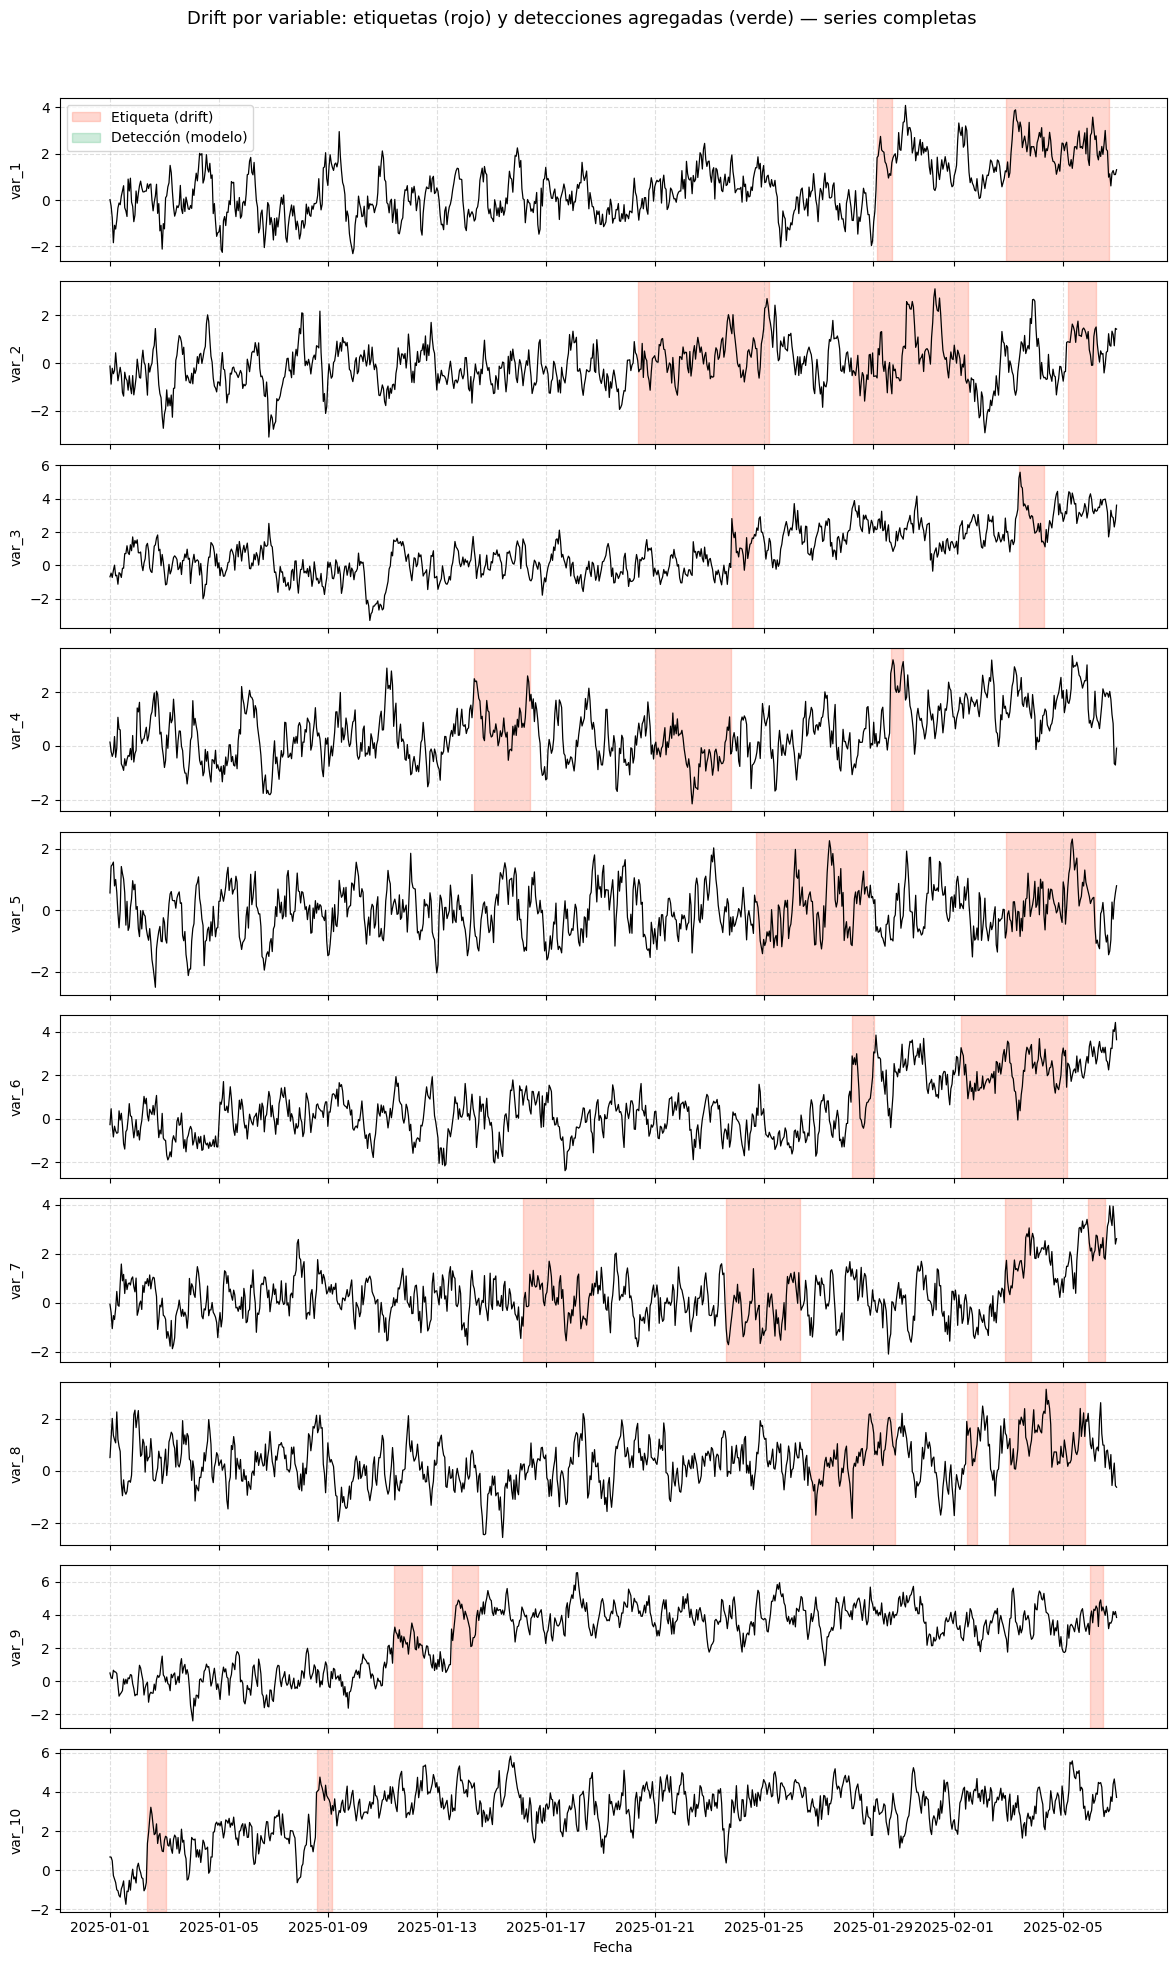

In [21]:
def plot_truth_vs_dets_like_3_1(df, var_names, labels_by_var, df_preds_var_daily=None,
                               figsize=(12, 2.0*10), alpha_truth=0.25, alpha_pred=0.25, lw_series=0.9):
    """
    Mismo estilo que la celda 3.1: subplots uno por variable, serie completa horaria,
    rojo = etiquetas horario (drift_var_i), verde = detecciones (diarias, expandidas a todo el día).
    df: dataframe horario con 'date_time' y columnas var_1..var_n y drift_var_i
    df_preds_var_daily: dataframe con columnas ['date','var','y_pred_var'] (puede contener varias combinaciones;
                        se toma el max por día/var)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # preparar agregación diaria de predicciones (si viene)
    preds_agg = None
    if df_preds_var_daily is not None and not df_preds_var_daily.empty:
        preds_agg = (df_preds_var_daily
                     .groupby(['date','var'], dropna=False)['y_pred_var']
                     .max()
                     .reset_index())
        preds_agg['date'] = pd.to_datetime(preds_agg['date']).dt.normalize()

    times = df['date_time']
    tmin, tmax = times.min(), times.max()

    n = len(var_names)
    fig, axes = plt.subplots(n, 1, figsize=(figsize[0], 2.0*n if isinstance(figsize, tuple) else figsize),
                             sharex=True)
    if n == 1:
        axes = [axes]

    # helper: convertir máscara booleana (horaria) a intervalos y pintarlos igual que en 3.1
    def _plot_mask_as_spans(ax, times_indexed, mask_bool, color, alpha):
        in_block = False
        start = None
        for i in range(len(mask_bool)):
            if mask_bool[i] and not in_block:
                start = times_indexed.iloc[i]
                in_block = True
            elif not mask_bool[i] and in_block:
                ax.axvspan(start, times_indexed.iloc[i], color=color, alpha=alpha)
                in_block = False
        if in_block:
            ax.axvspan(start, times_indexed.iloc[-1], color=color, alpha=alpha)

    # precomputar columna normalizada por día del df horario (para máscara rápida)
    df_days = df['date_time'].dt.normalize()

    for ax, v in zip(axes, var_names):
        # serie
        ax.plot(times, df[v], lw=lw_series, label=v, color='black')

        # verdad horario (drift_var_i) -> asumir columna labels_by_var[v] existe en df
        lbl = labels_by_var.get(v)
        if lbl is not None and lbl in df.columns:
            mask_truth = df[lbl].fillna(False).astype(bool).values
            _plot_mask_as_spans(ax, df['date_time'], mask_truth, color='tomato', alpha=alpha_truth)

        # detecciones: si hay preds_agg, expandir días detectados a máscara horaria
        if preds_agg is not None:
            p = preds_agg.loc[preds_agg['var'] == v, ['date','y_pred_var']].copy()
            if not p.empty:
                days_detected = set(p.loc[p['y_pred_var'].astype(int)==1, 'date'].tolist())
                if days_detected:
                    mask_pred = df_days.isin(days_detected).values
                    _plot_mask_as_spans(ax, df['date_time'], mask_pred, color='mediumseagreen', alpha=alpha_pred)

        ax.set_ylabel(v)
        ax.grid(True, ls='--', alpha=0.4)

    axes[-1].set_xlabel('Fecha')
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color='tomato', alpha=alpha_truth, label='Etiqueta (drift)')
    green_patch = mpatches.Patch(color='mediumseagreen', alpha=alpha_pred, label='Detección (modelo)')
    axes[0].legend(handles=[red_patch, green_patch], loc='upper left')
    fig.suptitle('Drift por variable: etiquetas (rojo) y detecciones agregadas (verde) — series completas', fontsize=13)
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

plot_truth_vs_dets_like_3_1(df, var_names, labels_by_var, df_preds_var_daily=df_preds_var_daily,
                            figsize=(12, 2.0*len(var_names)))